In [2]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('Zomato.csv')


In [4]:
df.head() 

,Unnamed: 0,restaurant name,restaurant type,rate (out of 5),num of ratings,avg cost (two people),online_order,table booking,cuisines type,Unnamed: 9,area,local address
0,0,#FeelTheROLL,Quick Bites,3.4,7,200,No,No,Fast Food,0,Bellandur,Bellandur
1,1,#L-81 Cafe,Quick Bites,3.9,48,400,Yes,No,"Fast Food, Beverages",1,"Byresandra,Tavarekere,Madiwala",HSR
2,2,#refuel,Cafe,3.7,37,400,Yes,No,"Cafe, Beverages",2,Bannerghatta Road,Bannerghatta Road
3,3,'@ Biryani Central,Casual Dining,2.7,135,550,Yes,No,"Biryani, Mughlai, Chinese",3,Marathahalli,Marathahalli
4,4,'@ The Bbq,Casual Dining,2.8,40,700,Yes,No,"BBQ, Continental, North Indian, Chinese, Bever...",4,Bellandur,Bellandur


In [5]:
df.describe()

,Unnamed: 0,rate (out of 5),num of ratings,avg cost (two people),Unnamed: 9
count,7105.000000,7105.000000,7105.000000,7105.000000,7105.000000
mean,3552.000000,3.480619,188.921042,535.952006,3552.000000
std,2051.181164,0.574133,592.171049,463.554352,2051.181164
min,0.000000,0.000000,1.000000,0.000000,0.000000
25%,1776.000000,3.200000,16.000000,300.000000,1776.000000
50%,3552.000000,3.500000,40.000000,400.000000,3552.000000
75%,5328.000000,3.800000,128.000000,600.000000,5328.000000
max,7104.000000,4.900000,16345.000000,6000.000000,7104.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7105 entries, 0 to 7104
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             7105 non-null   int64  
 1   restaurant name        7105 non-null   str    
 2   restaurant type        7105 non-null   str    
 3   rate (out of 5)        7105 non-null   float64
 4   num of ratings         7105 non-null   int64  
 5   avg cost (two people)  7105 non-null   int64  
 6   online_order           7105 non-null   str    
 7   table booking          7105 non-null   str    
 8   cuisines type          7105 non-null   str    
 9   Unnamed: 9             7105 non-null   int64  
 10  area                   7105 non-null   str    
 11  local address          7105 non-null   str    
dtypes: float64(1), int64(4), str(7)
memory usage: 1.2 MB


In [7]:
df.shape

(7105, 12)

In [8]:
df.isnull().sum()

Unnamed: 0               0
restaurant name          0
restaurant type          0
rate (out of 5)          0
num of ratings           0
avg cost (two people)    0
online_order             0
table booking            0
cuisines type            0
Unnamed: 9               0
area                     0
local address            0
dtype: int64

In [9]:
df.columns

Index(['Unnamed: 0', 'restaurant name', 'restaurant type', 'rate (out of 5)',
       'num of ratings', 'avg cost (two people)', 'online_order',
       'table booking', 'cuisines type', 'Unnamed: 9', 'area',
       'local address'],
      dtype='str')

In [10]:
df['rate (out of 5)'].describe()

count    7105.000000
mean        3.480619
std         0.574133
min         0.000000
25%         3.200000
50%         3.500000
75%         3.800000
max         4.900000
Name: rate (out of 5), dtype: float64

In [11]:
df.dtypes

Unnamed: 0                 int64
restaurant name              str
restaurant type              str
rate (out of 5)          float64
num of ratings             int64
avg cost (two people)      int64
online_order                 str
table booking                str
cuisines type                str
Unnamed: 9                 int64
area                         str
local address                str
dtype: object

In [12]:
df['restaurant type'].value_counts()

restaurant type
Quick Bites                  2840
Casual Dining                1634
Cafe                          403
Delivery                      358
Takeaway, Delivery            289
                             ... 
Food Court, Beverage Shop       1
Quick Bites, Food Court         1
Casual Dining, Sweet Shop       1
Quick Bites, Meat Shop          1
Club, Casual Dining             1
Name: count, Length: 81, dtype: int64

In [13]:
df['area'].value_counts()

area
Byresandra,Tavarekere,Madiwala    798
Bannerghatta Road                 552
Brookefield                       477
Brigade Road                      464
Indiranagar                       455
Electronic City                   403
Malleshwaram                      402
Kalyan Nagar                      384
Bellandur                         361
Banashankari                      359
Whitefield                        261
Marathahalli                      260
HSR                               241
Basavanagudi                      214
New BEL Road                      168
Koramangala 4th Block             162
Rajajinagar                       148
Lavelle Road                      141
Jayanagar                         127
Frazer Town                       126
Sarjapur Road                     108
Old Airport Road                   91
Church Street                      77
Koramangala 6th Block              71
JP Nagar                           69
Kammanahalli                       65
Koraman

In [14]:
df['area_clean'] = df['area'].str.split(',').str[-1].str.strip()

# Verify the fix
print("Before:", df['area'].value_counts().head(5))
print("\nAfter:", df['area_clean'].value_counts().head(5))
print(f"\nUnique areas reduced from {df['area'].nunique()} to {df['area_clean'].nunique()}")

# Check specific example
print("\nExample fix:")
print(df[df['area'].str.contains('Byresandra')][['area', 'area_clean']].head(3))

Before: area
Byresandra,Tavarekere,Madiwala    798
Bannerghatta Road                 552
Brookefield                       477
Brigade Road                      464
Indiranagar                       455
Name: count, dtype: int64

After: area_clean
Madiwala             798
Bannerghatta Road    552
Brookefield          477
Brigade Road         464
Indiranagar          455
Name: count, dtype: int64

Unique areas reduced from 30 to 30

Example fix:
                             area area_clean
1  Byresandra,Tavarekere,Madiwala   Madiwala
8  Byresandra,Tavarekere,Madiwala   Madiwala
9  Byresandra,Tavarekere,Madiwala   Madiwala


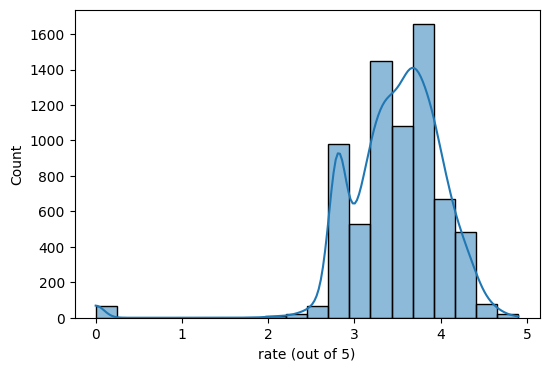

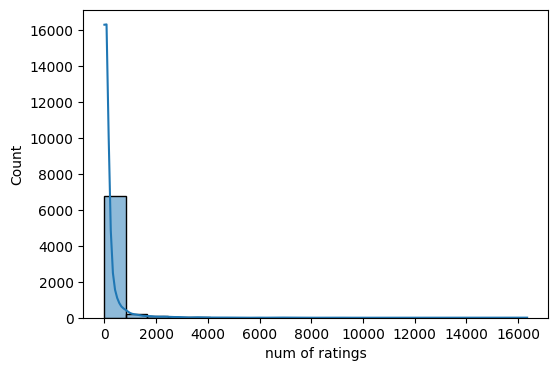

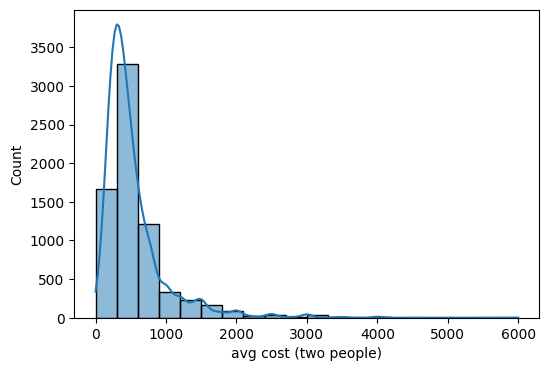

In [15]:
numerical_colums= ['rate (out of 5)','num of ratings', 'avg cost (two people)']
for col in numerical_colums:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)

In [16]:
df['restaurant type'].value_counts().head(20)

restaurant type
Quick Bites                   2840
Casual Dining                 1634
Cafe                           403
Delivery                       358
Takeaway, Delivery             289
Dessert Parlor                 217
Bakery                         154
Casual Dining, Bar             123
Beverage Shop                  118
Bar                             82
Food Court                      80
Fine Dining                     79
Lounge                          58
Bar, Casual Dining              54
Mess                            48
Sweet Shop                      46
Kiosk                           36
Pub                             34
Sweet Shop, Quick Bites         31
Beverage Shop, Quick Bites      29
Name: count, dtype: int64

In [17]:
df.columns


Index(['Unnamed: 0', 'restaurant name', 'restaurant type', 'rate (out of 5)',
       'num of ratings', 'avg cost (two people)', 'online_order',
       'table booking', 'cuisines type', 'Unnamed: 9', 'area', 'local address',
       'area_clean'],
      dtype='str')

In [18]:
print(df['restaurant type'].str.contains('Quick Bites').astype(int).head(10))

0    1
1    1
2    0
3    0
4    0
5    0
6    0
7    0
8    1
9    0
Name: restaurant type, dtype: int64


In [19]:
main_types = [
    'Quick Bites', 'Casual Dining', 'Cafe',
    'Delivery', 'Dessert Parlor', 'Bakery',
    'Beverage Shop', 'Bar', 'Food Court',
    'Fine Dining', 'Lounge', 'Mess', 'Sweet Shop', 'Pub'
]
for i in main_types:
    col_name = i.lower().replace(' ','_')
    df['is_'+col_name]=df['restaurant type'].str.contains(i).astype(int)

In [20]:
binary_cols = ['is_' + i.lower().replace(' ', '_') for i in main_types]
print(df[binary_cols].sum())


is_quick_bites       3000
is_casual_dining     1928
is_cafe               504
is_delivery           647
is_dessert_parlor     298
is_bakery             217
is_beverage_shop      175
is_bar                279
is_food_court          96
is_fine_dining         89
is_lounge              79
is_mess                49
is_sweet_shop          91
is_pub                 88
dtype: int64


In [21]:
df = df.rename(columns={
    'restaurant name': 'name',
    'restaurant type': 'rest_type',
    'rate (out of 5)': 'rate',
    'num of ratings': 'num_ratings',
    'avg cost (two people)': 'avg_cost',
    'table booking': 'table_booking',
    'cuisines type': 'cuisines',
    'local address': 'local_address'
})

In [22]:
df.columns.to_list

<bound method IndexOpsMixin.tolist of Index(['Unnamed: 0', 'name', 'rest_type', 'rate', 'num_ratings', 'avg_cost',
       'online_order', 'table_booking', 'cuisines', 'Unnamed: 9', 'area',
       'local_address', 'area_clean', 'is_quick_bites', 'is_casual_dining',
       'is_cafe', 'is_delivery', 'is_dessert_parlor', 'is_bakery',
       'is_beverage_shop', 'is_bar', 'is_food_court', 'is_fine_dining',
       'is_lounge', 'is_mess', 'is_sweet_shop', 'is_pub'],
      dtype='str')>

In [23]:
df = df.drop(columns=['Unnamed: 0', 'Unnamed: 9'], errors='ignore')
print(df.columns.tolist())
print(df.shape)
df['area_avg_rating']= df.groupby('area_clean')['rate'].transform('mean')

['name', 'rest_type', 'rate', 'num_ratings', 'avg_cost', 'online_order', 'table_booking', 'cuisines', 'area', 'local_address', 'area_clean', 'is_quick_bites', 'is_casual_dining', 'is_cafe', 'is_delivery', 'is_dessert_parlor', 'is_bakery', 'is_beverage_shop', 'is_bar', 'is_food_court', 'is_fine_dining', 'is_lounge', 'is_mess', 'is_sweet_shop', 'is_pub']
(7105, 25)


In [24]:
df['area_avg_cost'] =df.groupby('area_clean')['avg_cost'].transform('mean')

In [25]:
print(df[['name', 'area_clean', 'avg_cost', 'area_avg_cost']].head(10))

                                   name         area_clean  avg_cost  \
0                          #FeelTheROLL          Bellandur       200   
1                            #L-81 Cafe           Madiwala       400   
2                               #refuel  Bannerghatta Road       400   
3                    '@ Biryani Central       Marathahalli       550   
4                            '@ The Bbq          Bellandur       700   
5                                  '@99         Whitefield       200   
6                               '@Italy       Banashankari       700   
7                  '@North Parontha Hut        Indiranagar       300   
8                              1000 B.C           Madiwala       300   
9  100ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ°C           Madiwala       450   

   area_avg_cost  
0     542.742382  
1     486.015038  
2     446.974638  
3     516.730769  
4     542.742382  
5     694.444444  
6     388.548747  
7     667.582418  
8     486.015038  
9     486.015038 

In [26]:
df['competition_density'] = df.groupby(
    ['area_clean', 'rest_type'])['name'].transform('count')

print(df[['name', 'area_clean', 'rest_type', 
          'competition_density']].head(10))

                                   name         area_clean  \
0                          #FeelTheROLL          Bellandur   
1                            #L-81 Cafe           Madiwala   
2                               #refuel  Bannerghatta Road   
3                    '@ Biryani Central       Marathahalli   
4                            '@ The Bbq          Bellandur   
5                                  '@99         Whitefield   
6                               '@Italy       Banashankari   
7                  '@North Parontha Hut        Indiranagar   
8                              1000 B.C           Madiwala   
9  100ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ°C           Madiwala   

            rest_type  competition_density  
0         Quick Bites                  118  
1         Quick Bites                  316  
2                Cafe                   33  
3       Casual Dining                   61  
4       Casual Dining                  101  
5  Takeaway, Delivery                   17  
6 

In [27]:
result = df.groupby(['area_clean', 'rest_type']).transform('count')
print(type(result))
print(result.shape)
print(result.head())

<class 'pandas.DataFrame'>
(7105, 26)
   name  rate  num_ratings  avg_cost  online_order  table_booking  cuisines  \
0   118   118          118       118           118            118       118   
1   316   316          316       316           316            316       316   
2    33    33           33        33            33             33        33   
3    61    61           61        61            61             61        61   
4   101   101          101       101           101            101       101   

   area  local_address  is_quick_bites  ...  is_bar  is_food_court  \
0   118            118             118  ...     118            118   
1   316            316             316  ...     316            316   
2    33             33              33  ...      33             33   
3    61             61              61  ...      61             61   
4   101            101             101  ...     101            101   

   is_fine_dining  is_lounge  is_mess  is_sweet_shop  is_pub  area

In [28]:
df.columns

Index(['name', 'rest_type', 'rate', 'num_ratings', 'avg_cost', 'online_order',
       'table_booking', 'cuisines', 'area', 'local_address', 'area_clean',
       'is_quick_bites', 'is_casual_dining', 'is_cafe', 'is_delivery',
       'is_dessert_parlor', 'is_bakery', 'is_beverage_shop', 'is_bar',
       'is_food_court', 'is_fine_dining', 'is_lounge', 'is_mess',
       'is_sweet_shop', 'is_pub', 'area_avg_rating', 'area_avg_cost',
       'competition_density'],
      dtype='str')

In [29]:
df.head()

,name,rest_type,rate,num_ratings,avg_cost,online_order,table_booking,cuisines,area,local_address,...,is_bar,is_food_court,is_fine_dining,is_lounge,is_mess,is_sweet_shop,is_pub,area_avg_rating,area_avg_cost,competition_density
0,#FeelTheROLL,Quick Bites,3.4,7,200,No,No,Fast Food,Bellandur,Bellandur,...,0,0,0,0,0,0,0,3.475900,542.742382,118
1,#L-81 Cafe,Quick Bites,3.9,48,400,Yes,No,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala",HSR,...,0,0,0,0,0,0,0,3.583960,486.015038,316
2,#refuel,Cafe,3.7,37,400,Yes,No,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road,...,0,0,0,0,0,0,0,3.430072,446.974638,33
3,'@ Biryani Central,Casual Dining,2.7,135,550,Yes,No,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli,...,0,0,0,0,0,0,0,3.407692,516.730769,61
4,'@ The Bbq,Casual Dining,2.8,40,700,Yes,No,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur,...,0,0,0,0,0,0,0,3.475900,542.742382,101


In [30]:
# Also save your dataframe
df.to_csv('zomato_progress.csv', index=False)

In [31]:
df = pd.read_csv('zomato_progress.csv')


In [32]:
df.columns

Index(['name', 'rest_type', 'rate', 'num_ratings', 'avg_cost', 'online_order',
       'table_booking', 'cuisines', 'area', 'local_address', 'area_clean',
       'is_quick_bites', 'is_casual_dining', 'is_cafe', 'is_delivery',
       'is_dessert_parlor', 'is_bakery', 'is_beverage_shop', 'is_bar',
       'is_food_court', 'is_fine_dining', 'is_lounge', 'is_mess',
       'is_sweet_shop', 'is_pub', 'area_avg_rating', 'area_avg_cost',
       'competition_density'],
      dtype='str')

In [33]:
df['table_booking'].value_counts()

table_booking
No     6361
Yes     744
Name: count, dtype: int64

In [34]:
df['online_order'] =df['online_order'].map({'Yes':1,'No':0})

In [35]:
df['table_booking'] = df['table_booking'].map({'Yes':1,'No':0})

In [36]:
df.head()

,name,rest_type,rate,num_ratings,avg_cost,online_order,table_booking,cuisines,area,local_address,...,is_bar,is_food_court,is_fine_dining,is_lounge,is_mess,is_sweet_shop,is_pub,area_avg_rating,area_avg_cost,competition_density
0,#FeelTheROLL,Quick Bites,3.4,7,200,0,0,Fast Food,Bellandur,Bellandur,...,0,0,0,0,0,0,0,3.475900,542.742382,118
1,#L-81 Cafe,Quick Bites,3.9,48,400,1,0,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala",HSR,...,0,0,0,0,0,0,0,3.583960,486.015038,316
2,#refuel,Cafe,3.7,37,400,1,0,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road,...,0,0,0,0,0,0,0,3.430072,446.974638,33
3,'@ Biryani Central,Casual Dining,2.7,135,550,1,0,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli,...,0,0,0,0,0,0,0,3.407692,516.730769,61
4,'@ The Bbq,Casual Dining,2.8,40,700,1,0,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur,...,0,0,0,0,0,0,0,3.475900,542.742382,101


In [37]:
df.columns

Index(['name', 'rest_type', 'rate', 'num_ratings', 'avg_cost', 'online_order',
       'table_booking', 'cuisines', 'area', 'local_address', 'area_clean',
       'is_quick_bites', 'is_casual_dining', 'is_cafe', 'is_delivery',
       'is_dessert_parlor', 'is_bakery', 'is_beverage_shop', 'is_bar',
       'is_food_court', 'is_fine_dining', 'is_lounge', 'is_mess',
       'is_sweet_shop', 'is_pub', 'area_avg_rating', 'area_avg_cost',
       'competition_density'],
      dtype='str')

In [38]:
df['price_position'] = df['avg_cost']/df['area_avg_cost']

In [39]:
df.head()

,name,rest_type,rate,num_ratings,avg_cost,online_order,table_booking,cuisines,area,local_address,...,is_food_court,is_fine_dining,is_lounge,is_mess,is_sweet_shop,is_pub,area_avg_rating,area_avg_cost,competition_density,price_position
0,#FeelTheROLL,Quick Bites,3.4,7,200,0,0,Fast Food,Bellandur,Bellandur,...,0,0,0,0,0,0,3.475900,542.742382,118,0.368499
1,#L-81 Cafe,Quick Bites,3.9,48,400,1,0,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala",HSR,...,0,0,0,0,0,0,3.583960,486.015038,316,0.823020
2,#refuel,Cafe,3.7,37,400,1,0,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road,...,0,0,0,0,0,0,3.430072,446.974638,33,0.894905
3,'@ Biryani Central,Casual Dining,2.7,135,550,1,0,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli,...,0,0,0,0,0,0,3.407692,516.730769,61,1.064384
4,'@ The Bbq,Casual Dining,2.8,40,700,1,0,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur,...,0,0,0,0,0,0,3.475900,542.742382,101,1.289746


In [40]:
df['cuisines'].value_counts()

cuisines
North Indian, Chinese                                         421
North Indian                                                  420
South Indian                                                  348
Fast Food                                                     140
South Indian, North Indian, Chinese                           128
                                                             ... 
Italian, Chinese, Japanese                                      1
Chinese, Naga                                                   1
Italian, Mexican, Mediterranean, North Indian, Continental      1
Cafe, Italian, Continental, Burger                              1
Turkish, Fast Food, Biryani, Chinese                            1
Name: count, Length: 2175, dtype: int64

In [41]:
all_cusine = df['cuisines'].str.split(",").explode().str.strip().unique()

In [42]:
all_cusine

<ArrowStringArray>
[   'Fast Food',    'Beverages',         'Cafe',      'Biryani',
      'Mughlai',      'Chinese',          'BBQ',  'Continental',
 'North Indian',      'Italian',
 ...
         'Paan',      'British',       'Sindhi',       'Indian',
   'Sri Lankan',    'Pan Asian',      'Russian',    'Raw Meats',
      'Belgian',    'Cantonese']
Length: 106, dtype: str

In [43]:
for i in all_cusine:
    col_name = i.lower().replace(" ","_")
    df["is_"+col_name]=df['cuisines'].str.contains(i).astype(int)

/var/folders/zy/_h0gzvdj74nfr2n0x8db16dm0000gn/T/ipykernel_6261/1785018635.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["is_"+col_name]=df['cuisines'].str.contains(i).astype(int)
/var/folders/zy/_h0gzvdj74nfr2n0x8db16dm0000gn/T/ipykernel_6261/1785018635.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["is_"+col_name]=df['cuisines'].str.contains(i).astype(int)
/var/folders/zy/_h0gzvdj74nfr2n0x8db16dm0000gn/T/ipykernel_6261/1785018635.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the re

In [44]:
df.columns

Index(['name', 'rest_type', 'rate', 'num_ratings', 'avg_cost', 'online_order',
       'table_booking', 'cuisines', 'area', 'local_address',
       ...
       'is_paan', 'is_british', 'is_sindhi', 'is_indian', 'is_sri_lankan',
       'is_pan_asian', 'is_russian', 'is_raw_meats', 'is_belgian',
       'is_cantonese'],
      dtype='str', length=133)

In [45]:
df.shape


(7105, 133)

In [46]:
df=df.drop(columns=['name', 'rest_type','cuisines', 'area','local_address'],errors='ignore')

In [47]:
df.columns

Index(['rate', 'num_ratings', 'avg_cost', 'online_order', 'table_booking',
       'area_clean', 'is_quick_bites', 'is_casual_dining', 'is_cafe',
       'is_delivery',
       ...
       'is_paan', 'is_british', 'is_sindhi', 'is_indian', 'is_sri_lankan',
       'is_pan_asian', 'is_russian', 'is_raw_meats', 'is_belgian',
       'is_cantonese'],
      dtype='str', length=128)

In [48]:
area_rating =df.groupby("area_clean")['rate'].mean()

In [49]:
print(dict(area_rating))

{'Banashankari': np.float64(3.5688022284122565), 'Bannerghatta Road': np.float64(3.430072463768116), 'Basavanagudi': np.float64(3.2523364485981308), 'Bellandur': np.float64(3.4759002770083103), 'Brigade Road': np.float64(3.6842672413793105), 'Brookefield': np.float64(3.4454926624737947), 'Church Street': np.float64(3.606493506493506), 'Electronic City': np.float64(3.3635235732009927), 'Frazer Town': np.float64(3.5174603174603174), 'HSR': np.float64(3.3763485477178423), 'Indiranagar': np.float64(3.5692307692307694), 'JP Nagar': np.float64(3.3260869565217392), 'Jayanagar': np.float64(3.510236220472441), 'Kalyan Nagar': np.float64(3.49375), 'Kammanahalli': np.float64(3.4953846153846153), 'Koramangala 4th Block': np.float64(3.5160493827160497), 'Koramangala 5th Block': np.float64(3.5285714285714285), 'Koramangala 6th Block': np.float64(1.356338028169014), 'Koramangala 7th Block': np.float64(3.5305555555555554), 'Lavelle Road': np.float64(3.630496453900709), 'MG Road': np.float64(3.540625),

In [50]:
df['encoded_area']=df['area_clean'].map(dict(area_rating))

/var/folders/zy/_h0gzvdj74nfr2n0x8db16dm0000gn/T/ipykernel_6261/955230570.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['encoded_area']=df['area_clean'].map(dict(area_rating))


In [51]:
df.head()

,rate,num_ratings,avg_cost,online_order,table_booking,area_clean,is_quick_bites,is_casual_dining,is_cafe,is_delivery,...,is_british,is_sindhi,is_indian,is_sri_lankan,is_pan_asian,is_russian,is_raw_meats,is_belgian,is_cantonese,encoded_area
0,3.4,7,200,0,0,Bellandur,1,0,0,0,...,0,0,0,0,0,0,0,0,0,3.475900
1,3.9,48,400,1,0,Madiwala,1,0,0,0,...,0,0,0,0,0,0,0,0,0,3.583960
2,3.7,37,400,1,0,Bannerghatta Road,0,0,1,0,...,0,0,0,0,0,0,0,0,0,3.430072
3,2.7,135,550,1,0,Marathahalli,0,1,0,0,...,0,0,0,0,0,0,0,0,0,3.407692
4,2.8,40,700,1,0,Bellandur,0,1,0,0,...,0,0,1,0,0,0,0,0,0,3.475900


In [52]:
import pickle
pickle.dump(area_rating, open('area_rating.pkl', 'wb'))

In [53]:
df= df.drop(columns="area_clean",errors="ignore")

In [54]:
df.columns

Index(['rate', 'num_ratings', 'avg_cost', 'online_order', 'table_booking',
       'is_quick_bites', 'is_casual_dining', 'is_cafe', 'is_delivery',
       'is_dessert_parlor',
       ...
       'is_british', 'is_sindhi', 'is_indian', 'is_sri_lankan', 'is_pan_asian',
       'is_russian', 'is_raw_meats', 'is_belgian', 'is_cantonese',
       'encoded_area'],
      dtype='str', length=128)

In [55]:
df.to_csv('zomato_cleaned.csv', index=False)

In [56]:
df = pd.read_csv('zomato_cleaned.csv')

In [57]:
df.sum()

rate               24729.8
num_ratings      1342284.0
avg_cost         3807939.0
online_order        3727.0
table_booking        744.0
                   ...    
is_russian             1.0
is_raw_meats           1.0
is_belgian             1.0
is_cantonese           1.0
encoded_area       24729.8
Length: 128, dtype: float64

In [58]:
is_colms = df.columns.str.startswith("is_")

In [59]:
print(df.columns[is_colms])

Index(['is_quick_bites', 'is_casual_dining', 'is_cafe', 'is_delivery',
       'is_dessert_parlor', 'is_bakery', 'is_beverage_shop', 'is_bar',
       'is_food_court', 'is_fine_dining',
       ...
       'is_paan', 'is_british', 'is_sindhi', 'is_indian', 'is_sri_lankan',
       'is_pan_asian', 'is_russian', 'is_raw_meats', 'is_belgian',
       'is_cantonese'],
      dtype='str', length=118)


In [60]:
is_sum = df[df.columns[is_colms]].sum()

In [61]:
print(is_sum[is_sum < 50])

is_mess          49
is_japanese      41
is_malaysian     15
is_vietnamese    18
is_korean        19
                 ..
is_pan_asian      2
is_russian        1
is_raw_meats      1
is_belgian        1
is_cantonese      1
Length: 66, dtype: int64


In [62]:
low_freq = is_sum[is_sum <50].index

In [63]:
df = df.drop(columns=low_freq,errors='ignore')

In [64]:
df.head()

,rate,num_ratings,avg_cost,online_order,table_booking,is_quick_bites,is_casual_dining,is_cafe,is_delivery,is_dessert_parlor,...,is_andhra,is_desserts,is_healthy_food,is_hyderabadi,is_bengali,is_mangalorean,is_juices,is_mexican,is_indian,encoded_area
0,3.4,7,200,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3.475900
1,3.9,48,400,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3.583960
2,3.7,37,400,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,3.430072
3,2.7,135,550,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,3.407692
4,2.8,40,700,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,3.475900


In [65]:
df.shape

(7105, 62)

In [66]:
df.to_csv('zomato_cleaned.csv',index=False)

In [67]:
import pickle
pickle.dump(df.drop(columns=['rate']).columns, open('feature_columns.pkl', 'wb'))

In [71]:
feature_columns = pickle.load(open("feature_columns.pkl",'rb'))

In [73]:
print([col for col in feature_columns if col.startswith('is_')])

['is_quick_bites', 'is_casual_dining', 'is_cafe', 'is_delivery', 'is_dessert_parlor', 'is_bakery', 'is_beverage_shop', 'is_bar', 'is_food_court', 'is_fine_dining', 'is_lounge', 'is_sweet_shop', 'is_pub', 'is_fast_food', 'is_beverages', 'is_biryani', 'is_mughlai', 'is_chinese', 'is_bbq', 'is_continental', 'is_north_indian', 'is_italian', 'is_arabian', 'is_sandwich', 'is_rolls', 'is_burger', 'is_kebab', 'is_asian', 'is_european', 'is_pizza', 'is_salad', 'is_street_food', 'is_thai', 'is_south_indian', 'is_kerala', 'is_seafood', 'is_american', 'is_steak', 'is_momos', 'is_mediterranean', 'is_finger_food', 'is_ice_cream', 'is_mithai', 'is_andhra', 'is_desserts', 'is_healthy_food', 'is_hyderabadi', 'is_bengali', 'is_mangalorean', 'is_juices', 'is_mexican', 'is_indian']
